## Les grandes parties qui doivent composés l'Analyse exploratoire des données(EDA):
-   **Etape 1. Import des bibliothéques**
-   **Etape 2. Chargement des données**
-   **Etape 3. Compréhension générale du dataset**
-   **Etape 4. Analyse de la qualité des données**
-   **Etape 5. Analyse statistique**
-   **Etape 6. Synthèse des variables pour la modélisation**
-   **Etape 7. Conclusion générale de l'EDA**

### **Etape 1 : Import des bibliothéques**

In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

# Affichage de toutes les colonnes
pd.set_option("display.max_columns", None)
print("2")


2


### **Etape 2 : Chargement des données**

In [3]:
# chargement des données
df = pd.read_csv("../data/raw/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### **Etape 3 : Compréhension générale du dataset**

In [4]:
# Afficher les premières lignes
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

#### 1. Premières observations :
**Nom des colonnes, format des valeurs : Signification des variables** : 

- Features : 
    -   PassengerId, int64 : identifiant unique du passager
    -   Pclass, int64 : Classe du billet 
    -   Name, object : Nom complet du passager
    -   Sex, object : Sexe du passager (Homme ou Femme)
    -   Age, float64 : age du passager 
    -   SibSp, int64 : Nombre de frères/soeurs ou conjoints à bords
    -   Parch, int64 : Nombre de parents/enfants à bord
    -   Ticket, object : Numéro du billet
    -   Fare, float64 : Prix du billet
    -   Cabin, object : Numéro de cabine
    -   Embarked, object : Port d'embarquement

- Target : 
        - Survived, int64 : Mort(0) ou Vivant(1)
    

#### 2. Observations sur le dataset : 

- Le dataset contient des infos individuelles sur chaque passager du titanic.
- Les premières lignes montre un mélange de variables numériques(Age,Fare,Pclass) et catégorielles(Sex,Embarked).
- La variable cible est Survived, codée en 0(mort) ou 1(vivant).
- Certaines colonnes, comme Cabin, présentent déjà des valeurs manquantes visibles.
- Les colonnes PassengerId, Name et Tocket semblent être des informations d'identification qui devront être étudiées pour déterminer leur utilité dans la modélisation.

#### 3. Les questions que l'on doit toujours se poser 

Lorsqu'on regarde les premières lignes, il faut se demander : 

-   Les données sont-elles cohérentes?

    Exemple : 
    -   Un age de 22 ans --> Cohérent
    -   Un tarif de 7,25 --> cohérent
    -   Un sexe male ou female --> cohérent

- Les formats sont-ils corrects?

    Exemple:
    -   Age est un nombre --> Oui
    -   Fare est un nombre décimal --> oui
    -   Name est une chaîne de caractères --> oui


- Observe-t-on déjà des anomalies?

    Exemple : 
    -   Une cellule vide dans Cabin
    -   Une valeur manquante dans Age
    -   Un format étrange dans Ticket 

#### 4. Conclusion des premières observations : 

Les premières observations montrent que le dataset contient des variables de fifférents types( numériques, catégorielles et textuelles).
Les valeurs semblent globalement cohérentes avec le contexte du problème.
Certaines colonnes présentent déjà des valeurs manquantes visibles, notamment Cabine, ce qui sera analysé plus en détail dans la partie consacrée à la qualité des données.




### **Etape 4 :  Analyse de la qualité des données** 

Voila les étapes à suivre :

-   1. Valeurs manquantes
-   2. Doublons
-   3. Cohérence des valeurs
-   4. Vérification du type de données
-   5. Valeurs aberrantes (outliers)
-   6. Conclusions

#### 4.1. Valeurs manquantes : Quelles colonnes contiennent des valeurs manquantes?

In [6]:
# En brut 
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# En pourcentages
(df.isnull().sum()/df.shape[0])*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

##### Trois colonnes manquantes : Age, Cabin, Embarked : Age : 19.8 % ; Cabin : 77% ; Embarked : 0,2% 

#### 4.2. Doublons : Existe-t-il des lignes dupliquées? 

In [8]:
df.duplicated().sum()

np.int64(0)

##### Pas de doublons dans le dataset si on en avait trouvé on s'en occuperai plus tard en les examinant avant de les supprimer

#### 4.3. Cohérences des données : Vérifier si les valeurs sont conforme à ce que l'on attends 



In [9]:
colonnes1 = ["Survived", "Pclass", "Sex", "SibSp"]
colonnes2 = ["Parch", "Fare", "Cabin", "Embarked"]




In [10]:
for i in colonnes1:
    print(df[i].value_counts(dropna=False))
    print("--------------------------------------------------")

Survived
0    549
1    342
Name: count, dtype: int64
--------------------------------------------------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
--------------------------------------------------
Sex
male      577
female    314
Name: count, dtype: int64
--------------------------------------------------
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
--------------------------------------------------


In [11]:
for i in colonnes2:
    print(df[i].value_counts(dropna=False))
    print("--------------------------------------------------")

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
--------------------------------------------------
Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
35.0000     1
28.5000     1
6.2375      1
14.0000     1
10.5167     1
Name: count, Length: 248, dtype: int64
--------------------------------------------------
Cabin
NaN            687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64
--------------------------------------------------
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64
--------------------------------------------------


Le jeu de données est globalement cohérent avec le problème de classification avec le problème étudié.
Il contient des variables numériques, catégorielles et textuelles décrivant les caractéristiques des passagers du Titanic.
La variable cible, Survived, est correctement identifiée et codée de manière binaire.

Les premières observations montrent que les formats des données sont globalement conformes aux attentes.
Quelques valeurs manquantes sont déjà visibles dans certaines colonnes : Age, Cabin et Embarked.
L'importance de ces valeurs manquantes sera étudiée dans l'étape suivante consacrée à la qualité des données.
Aucune incohérence majeure n'a été identifiée lors de cet aperçu initial.

#### 4.4 - Vérifications des types de données

**Objectif : Vérifier que chaque variable possède un type compatible avec son interprétation métier.**

In [20]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Tout est ok pour les types attendus

#### 4.5 - Recherche de valeurs aberrantes

**Objectif : Identifier les observation extrêmes pouvant influencer le futur modèle. Faisons ça pour les colonnes numériques :**
-   Age
-   SIbSp
-   Parch
-   Fare


**On ne le fait pas pour la target, PassengerId et Pclass car respectivement : variable cible binaire, identifiant non mesurable, catégorie pas une quantité**

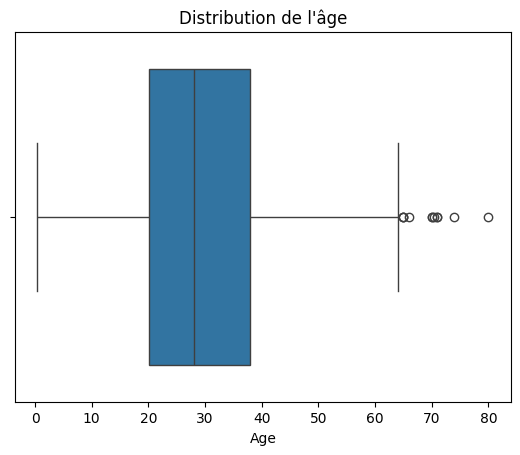

In [21]:
# Age
sns.boxplot(x=df["Age"])
plt.title("Distribution de l'âge")
plt.show()

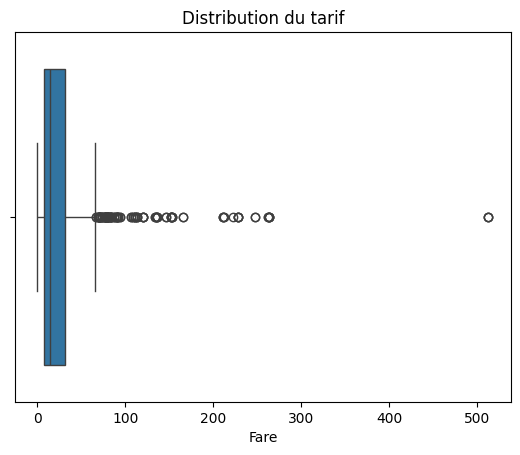

In [22]:
# Fare
sns.boxplot(x=df["Fare"])
plt.title("Distribution du tarif")
plt.show()

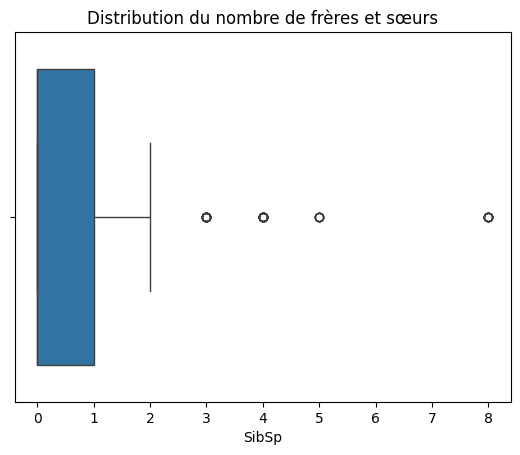

In [23]:
# SibSp
sns.boxplot(x=df["SibSp"])
plt.title("Distribution du nombre de frères et sœurs")
plt.show()

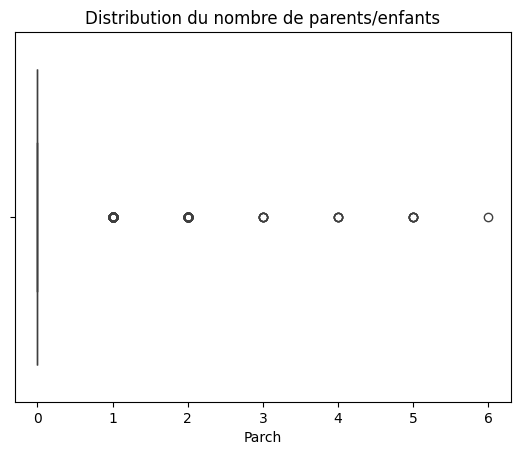

In [24]:
# Parch
sns.boxplot(x=df["Parch"])
plt.title("Distribution du nombre de parents/enfants")
plt.show()

#### Conclusions sur les valeurs aberrantes :

##### Variable Age:
-   Le boxplot de la variable Age, met en évidence la présence de quelques valeurs en dehors des moustaches.
-   Ces observations correspondent principalement à de très jeunes passagers ou très âgés. 
-   Au regard du contexte du titanic, ces valeurs restent plausibles et ne semblent pas être d'érreurs de saisies.
-   Elles seront conservées sauf si une analyse ultérieure justifie un traitement particulier.

##### Variable fare:
-   Le boxplot de la variable Fare révèle la présence de nombreuses valeurs extrêmes, avec quelques billets dont le prix est très supérieur à la majorité des observations.
-   Cette forte dispersion est cohérente avec les différences importantes de classe et de type de cabine à bord du Titanic.
-   Ces valeurs ne sont donc pas considérées comme des erreurs de mesure, mais comme des observations réelles qu'il conviendra de prendre en compte lors du prétraitement et du choix des modèles.

##### Variable SibSp:
-   Le boxplot de la variable SibSp montre quelques valeurs élevées correspondant à des passagers voyageant avec un nombre important de frères, sœurs ou conjoints.
-   Bien que peu fréquentes, ces observations restent cohérentes avec le contexte du jeu de données et ne constituent pas des anomalies évidentes.

##### Variable Parch:
-   Le boxplot de la variable Parch met également en évidence quelques valeurs plus élevées que la majorité des observations.
-   Celles-ci correspondent à des passagers voyageant avec plusieurs parents ou enfants. Ces valeurs sont rares mais plausibles et ne semblent pas résulter d'erreurs de saisie.





**L'analyse des boxplots met en évidence la présence de valeurs extrêmes, principalement pour les variables Fare, SibSp et Parch. Toutefois, ces observations apparaissent cohérentes avec le contexte du jeu de données et ne peuvent pas être considérées comme des erreurs. À ce stade, aucune suppression n'est envisagée. Une analyse complémentaire permettra de déterminer si un traitement spécifique (transformation, conservation ou méthode robuste) est nécessaire lors du prétraitement.**

#### 4.6 - Conclusion de cette partie 4 : Qualité des données

-   L'analyse de la qualité des données montre que le dataset est globalement exploitable pour un projet de classification. 
-   Néanmoins, plusieurs traitements seront nécessaires avant l'entraînement des modèles, notamment la gestion des valeurs manquantes, l'étude des valeurs aberrantes et la préparation des variables pour les algorithmes de Machine Learning.

### 5. **Analyse statistique(EDA approfondie)**

**Objectif: La question à se poser est, que m'apprennent les données sur le problème de prédiction?**

-   1.  **Analyse univariée**
    -   1. Variables Numériques
    -   2. Variables object
    -   3. Conclusion de l'analyse univariée
-   2.  **Analyse bivariée**
    -   1. Sex vs Survived 
        -   a. Que regarde-t-on
        -   b. Questions
        -   c. Conclusion attendue
    -   2. Pclass vs Survived
        -   a. Que regarde-t-on
        -   b. Questions
        -   c. Conclusion 
    -   3. Age vs Survived
        -   a. Que regarde-t-on
        -   b. Questions
        -   c. Conclusion 
    -   4. Fare vs Survived
        -   a. Questions
        -   b. Conclusion 
    -   5. SibSp vs Survived
        -   a. Que regarde-t-on
        -   b. Conclusion 
    -   6. Parch vs Survived
    -   7. Embarked vs Survived
    -   8. Conclusions
-   3.  **Analyse multivariée**
    -   1.  Sex, Pclass et Survived
        -   a. Que représente le graphique
        -   b. Ce que l'on observe
        -   c. Conclusion
    -   2.  Age, Sex et Survived
    -   3.  Embarked, Pclass et Survived
        -   a. Que faut-il observer
        -   b. Pose toi les questions suivantes
        -   c. Explication
        -   d. Une interprétation métier
    -   4.  Fare, Pclass et Survived
        -   a. Comment analyser ce graphique
        -   b. Analyse
        -   c. Interprétation
        -   d. Conclusion
    -   5.  Age, Pclass et Survived
        -   a. Analyse
        -   b. Interprétation
        -   c. Conclusion
    -   6.  Conclusion - Analyse multivariée
-   4.  **Corrélations**
    -   1. Préparations des données pour la corrélation
    -   2. Calcul de la matrice de corrélation
    -   3. Visualisation
    -   4. Analyse des corrélation - Conclusion
-   5.  **Tests statistiques si necéssaire**
    -   1. Rappels des choses à savoir sur les tests
    -   2. Test du Chi2 : Sex et Survived
    -   3. Test du Chi2 : Pclass et Survived
    -   4. Test de Mann-Whitney : Âge et Survie
    -   5. Conclusion de la partie 5.5 - Tests statistiques si nécéssaires

-   6.  **Conclusions**

#### 5.1 - **Analyse univariée**

Objectif : étudier chaque variable individuellement. On regarde sa distribution, son équillibre, ses caractéristiques.

#### 1. Variable Numériques

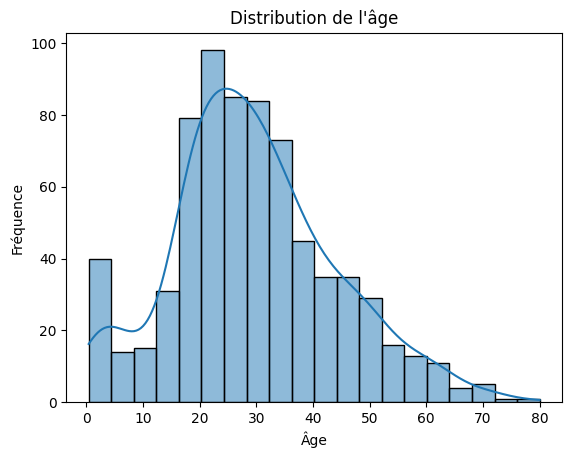

In [25]:
# Age 
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Distribution de l'âge")
plt.xlabel("Âge")
plt.ylabel("Fréquence")
plt.show()

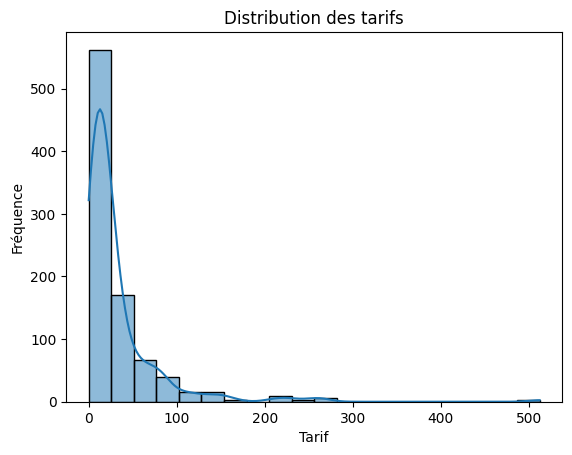

In [26]:
# Fare
sns.histplot(df["Fare"], bins=20, kde=True)
plt.title("Distribution des tarifs")
plt.xlabel("Tarif")
plt.ylabel("Fréquence")
plt.show()

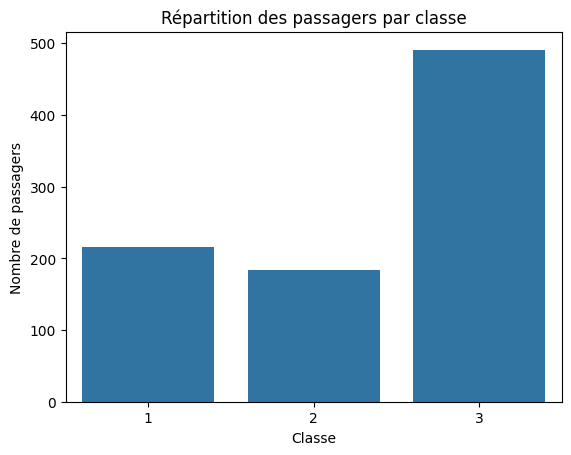

In [27]:
# classe
sns.countplot(x=df["Pclass"])
plt.title("Répartition des passagers par classe")
plt.xlabel("Classe")
plt.ylabel("Nombre de passagers")
plt.show()

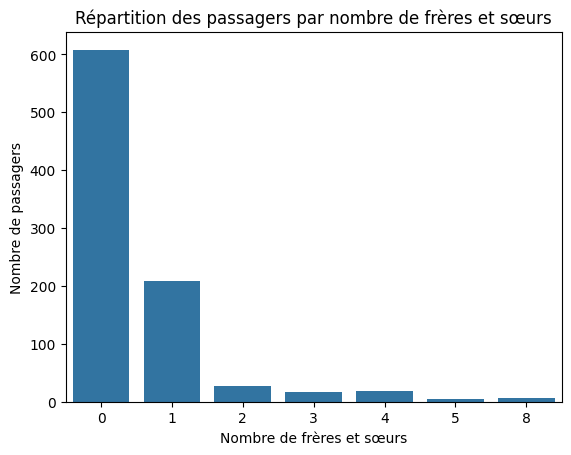

In [28]:
# SibSp
sns.countplot(x=df["SibSp"])
plt.title("Répartition des passagers par nombre de frères et sœurs")
plt.xlabel("Nombre de frères et sœurs")
plt.ylabel("Nombre de passagers")
plt.show()

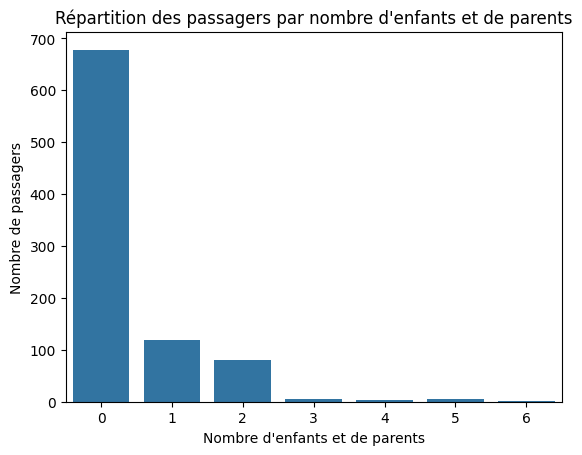

In [29]:
# Parch
sns.countplot(x=df["Parch"])
plt.title("Répartition des passagers par nombre d'enfants et de parents")
plt.xlabel("Nombre d'enfants et de parents")
plt.ylabel("Nombre de passagers")
plt.show()

Text(0, 0.5, 'Nombre de passagers')

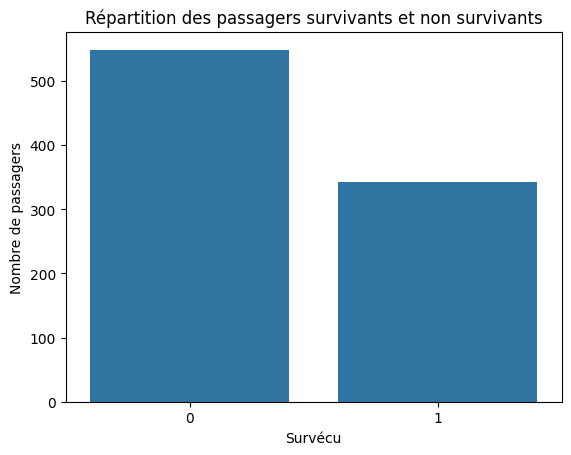

In [30]:
# Survived
sns.countplot(x=df["Survived"])
plt.title("Répartition des passagers survivants et non survivants")
plt.xlabel("Survécu")
plt.ylabel("Nombre de passagers")

**conclusion :**

-   L'analyse univariée des variables numériques a permis de mieux comprendre leur distribution et leurs principales caractéristiques.
-   La variable cible **Survived** met en évidence un nombre plus important de passagers non survivants (**549**) que de survivants (**342**), traduisant un léger déséquilibre entre les deux classes.
-   La variable **Pclass** montre que la majorité des passagers voyageaient en **troisième** classe, suivie de la **première** puis de la **deuxième** classe.
-   La distribution de **Age** est relativement concentrée autour de **30 ans**, avec quelques valeurs extrêmes correspondant à des nourrissons et à des personnes âgées. Ces observations restent cohérentes avec la population étudiée.
-   Les variables **SibSp** et **Parch** révèlent que la plupart des passagers voyageaient **seuls** ou avec **un nombre très limité de proches**. Les familles nombreuses sont peu représentées dans le jeu de données.
-   Enfin, la variable **Fare** présente une distribution fortement asymétrique à droite. La majorité des passagers a payé un tarif relativement faible, tandis qu'un petit nombre de billets atteint des montants beaucoup plus élevés.

--> Dans l'ensemble, cette analyse met en évidence des distributions variées selon les variables étudiées. 
--> Certaines, comme Fare, présentent une forte dispersion, tandis que d'autres, comme SibSp et Parch, sont concentrées sur un nombre limité de valeurs. 
--> Ces premières observations constituent une base essentielle pour l'analyse bivariée, qui permettra d'étudier l'influence de ces variables sur la survie des passagers.

#### 2. Variables object

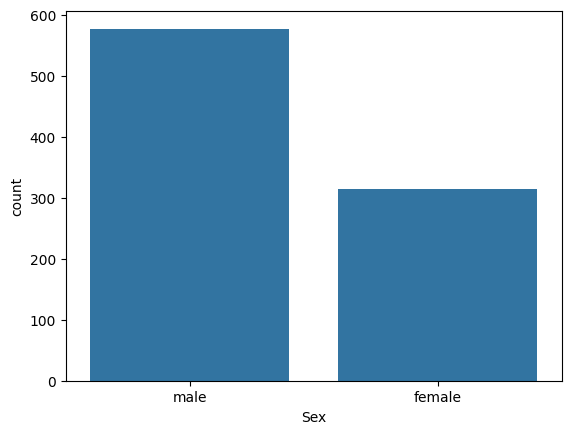

In [31]:
# Sex
sns.countplot(data=df, x="Sex")
plt.show()

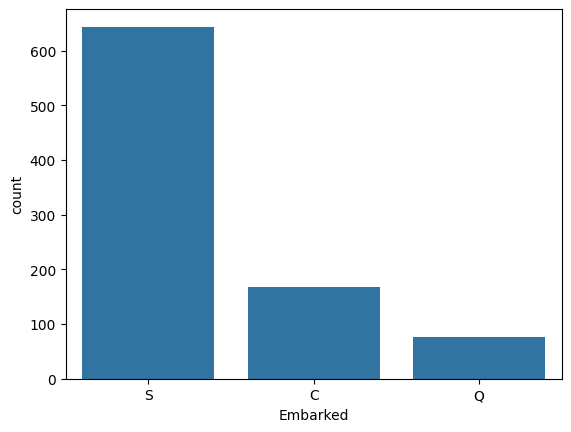

In [32]:
# Embarked
sns.countplot(data=df, x="Embarked")
plt.show()


**Conclusion** – Analyse univariée des variables Sex et Embarked

-   L'analyse univariée des variables catégorielles met en évidence une majorité de passagers de sexe masculin (577 contre 314 femmes). 
-   Concernant le port d'embarquement, la plupart des passagers ont embarqué à Southampton (S), suivi de Cherbourg (C) puis de **Queenstown (Q). Deux valeurs manquantes sont également présentes dans la variable **Embarked**.
-   Ces observations montrent que les catégories sont réparties de manière inégale, ce qui pourra influencer l'analyse de leur relation avec la variable cible **Survived**. Les valeurs manquantes de **Embarked** devront être prises en compte lors du prétraitement des données.

#### 3. Conclusion générale – Analyse univariée

-   L'analyse univariée a permis d'étudier individuellement l'ensemble des variables du jeu de données et d'en dégager les principales caractéristiques. Les distributions observées montrent que la majorité des passagers voyageaient en troisième classe, étaient de sexe masculin et avaient embarqué à Southampton. 
-   Les variables Age et Fare présentent une dispersion plus importante, notamment Fare, dont la distribution est fortement asymétrique en raison de quelques tarifs très élevés.   
-   Les variables SibSp et Parch indiquent que la plupart des passagers voyageaient seuls ou avec un nombre limité de proches. Par ailleurs, la variable cible Survived met en évidence un léger déséquilibre entre les passagers survivants et non survivants.

Dans l'ensemble, cette analyse fournit une première compréhension de la structure du jeu de données et met en évidence plusieurs caractéristiques qui pourront influencer la modélisation. Ces observations serviront de base à l'analyse bivariée, dont l'objectif sera d'étudier les relations entre les variables explicatives et la variable cible Survived.

#### 5.2 - **Analyse bivariée**

**Objectif:**
Étudier les relations entre les variables explicatives et la variable cible Survived afin d'identifier les facteurs susceptibles d'influencer la survie des passagers.


##### 1. **Sexe vs Survived**


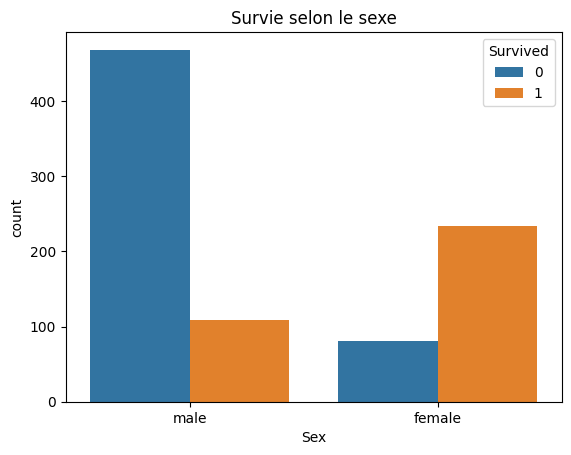

In [33]:
sns.countplot(data=df,
              x="Sex",
              hue="Survived")

plt.title("Survie selon le sexe")
plt.show()

##### a. Que regardes-t'on ?

On compares :
-   les hommes survivants
-   les hommes non survivants
-   les femmes survivantes
-   les femmes non survivantes

##### b. Questions
-   Les femmes survivent-elles davantage ?
-   Les hommes survivent-ils davantage ?
-   Existe-t-il une différence importante ?

##### c. Conclusion attendue

Le graphique met en évidence une différence marquée entre les hommes et les femmes. 
Les femmes présentent une proportion de survivantes nettement plus élevée que les hommes, tandis que les hommes sont majoritairement représentés parmi les non-survivants. Le sexe semble donc être une variable fortement liée à la survie.

##### 2. **Pclass vs Survived**



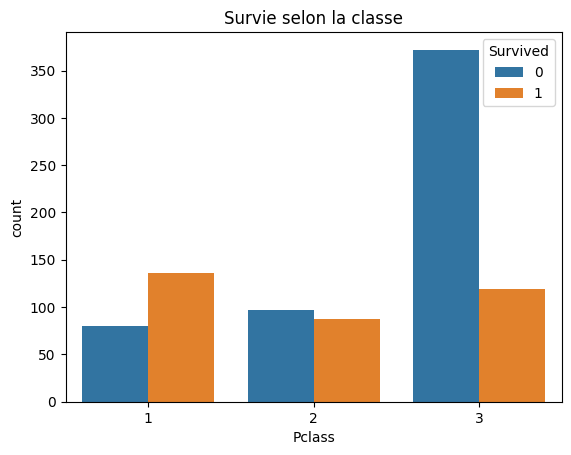

In [34]:
sns.countplot(data=df,
              x="Pclass",
              hue="Survived")

plt.title("Survie selon la classe")
plt.show()

##### a. Que regardes-t'on ?

Comparer :
-   Classe 1
-   Classe 2
-   Classe 3

##### b. Questions:

-   Quelle classe survit le plus ?
-   Quelle classe survit le moins ?

##### c. Conclusion

Les passagers de première classe présentent une proportion de survivants plus importante que ceux des deuxième et troisième classes. À l'inverse, la troisième classe enregistre le plus grand nombre de décès. La classe de voyage semble donc influencer les chances de survie.

##### 3. **Age vs Survived**


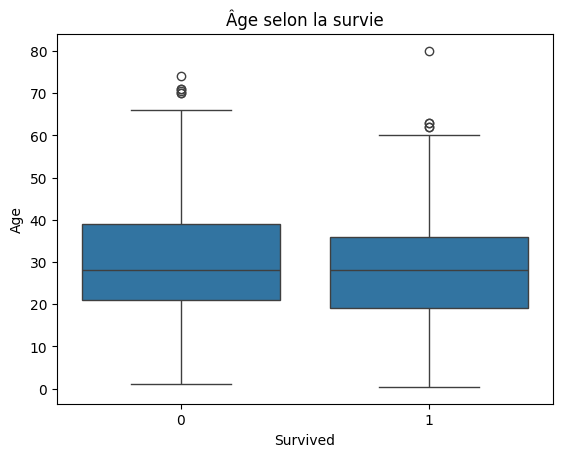

In [35]:
sns.boxplot(data=df,
            x="Survived",
            y="Age")

plt.title("Âge selon la survie")
plt.show()

##### a. Que regardes-t'on ?

Comparer :
-   âge des survivants
-   âge des non-survivants

##### b. Questions:
-   Les survivants sont-ils plus jeunes ?
-   Les distributions sont-elles proches ?

##### c. Conclusion:

Les distributions d'âge des survivants et des non-survivants sont relativement proches. Quelques différences peuvent être observées, notamment une proportion plus importante de jeunes enfants parmi les survivants, mais l'âge semble avoir un effet moins marqué que le sexe ou la classe.

##### 4. **Fare vs Survived**


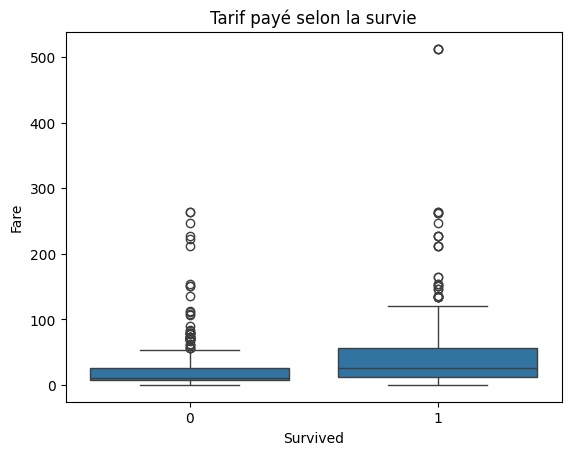

In [36]:
sns.boxplot(data=df,
            x="Survived",
            y="Fare")

plt.title("Tarif payé selon la survie")
plt.show()

##### a. Questions:

Les survivants ont-ils payé plus cher ?

##### b. Conclusion
    
Les survivants ont, en moyenne, payé des tarifs plus élevés que les non-survivants. Cette observation est cohérente avec le fait que les billets les plus coûteux étaient généralement associés aux classes supérieures, qui bénéficiaient de meilleures conditions d'évacuation.

##### 5. **SibSp vs Survived**


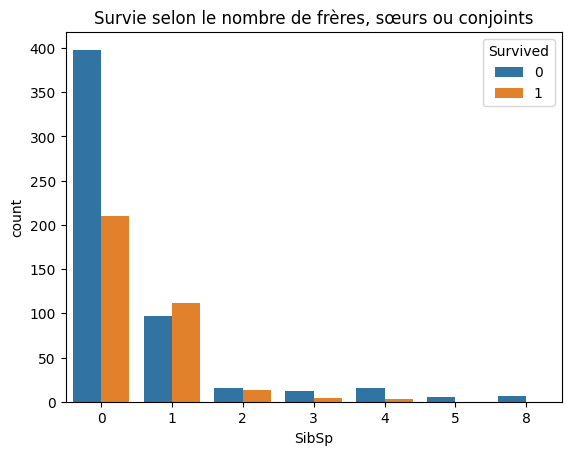

In [37]:
sns.countplot(data=df,
              x="SibSp",
              hue="Survived")

plt.title("Survie selon le nombre de frères, sœurs ou conjoints")
plt.show()

##### a. Que regardes-t'on ?

Comparer les taux de survie selon :

-   0 proche
-   1 proche
-   2 proches
etc.

##### b. Conclusion

Les passagers voyageant seuls ou avec un nombre limité de proches semblent présenter de meilleures chances de survie que ceux appartenant à des familles nombreuses. Toutefois, les effectifs des valeurs élevées étant faibles, cette observation devra être interprétée avec prudence.

##### 6. **Parch vs Survived**


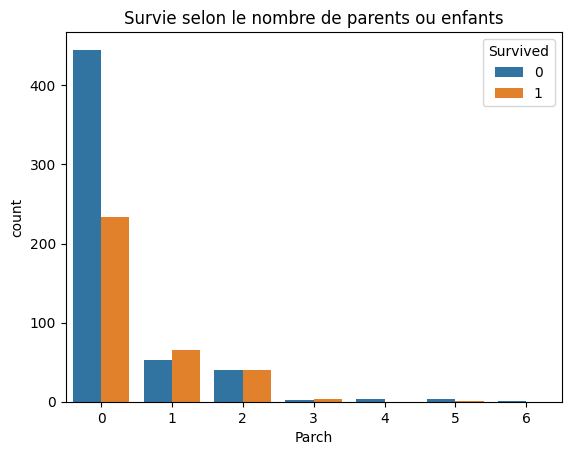

In [38]:
sns.countplot(data=df,
              x="Parch",
              hue="Survived")

plt.title("Survie selon le nombre de parents ou enfants")
plt.show()

Conclusion

Une tendance similaire est observée pour la variable Parch. Les passagers accompagnés d'un petit nombre de proches semblent présenter de meilleures chances de survie que ceux voyageant seuls ou en très grands groupes familiaux. Cette relation paraît toutefois moins marquée que celle observée pour le sexe ou la classe.

##### 7. **Embarked vs Survived**


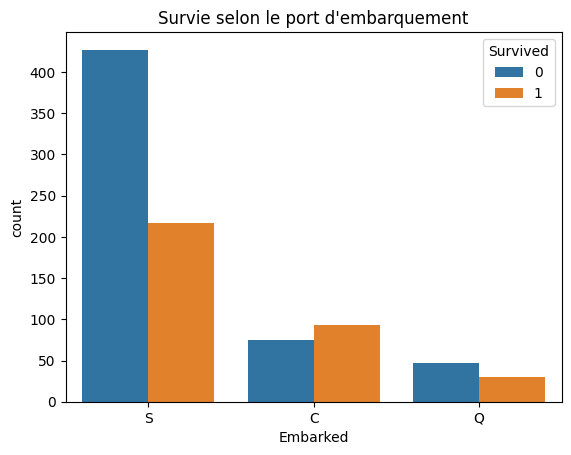

In [39]:
sns.countplot(data=df,
              x="Embarked",
              hue="Survived")

plt.title("Survie selon le port d'embarquement")
plt.show()

Conclusion

Les proportions de survivants varient selon le port d'embarquement. Certaines différences sont observées entre Southampton, Cherbourg et Queenstown, mais elles semblent moins prononcées que celles liées au sexe ou à la classe sociale.

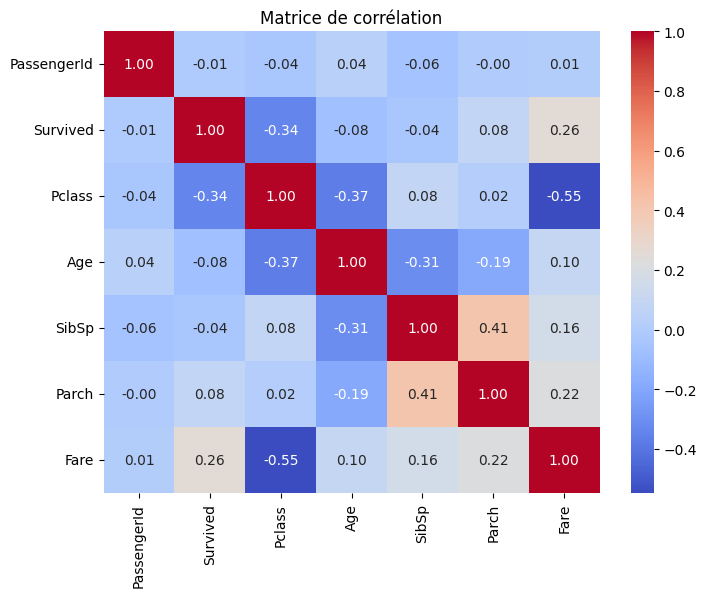

In [40]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Matrice de corrélation")

plt.show()

##### 8. **Conclusion – Analyse bivariée**

-   L'analyse bivariée a permis d'étudier les relations entre les variables explicatives et la variable cible Survived. Les résultats montrent que certaines variables semblent avoir une influence plus importante sur la survie des passagers.
-   Le sexe apparaît comme l'un des facteurs les plus discriminants, les femmes présentant une proportion de survivantes nettement supérieure à celle des hommes. 
-   La classe de voyage (Pclass) influence également la survie, les passagers de première classe ayant davantage de chances de survivre que ceux de deuxième et surtout de troisième classe.
-   Les variables Fare, Age, SibSp et Parch montrent également des différences entre survivants et non-survivants, mais leur influence semble moins marquée. 
-   Le port d'embarquement (Embarked) présente quelques variations de taux de survie selon les catégories, sans que celles-ci soient aussi prononcées que pour le sexe ou la classe.


#### 5.3 **Analyse multivariée**

**Objectif:**

Étudier les interactions entre plusieurs variables afin d'identifier des profils de passagers présentant des probabilités de survie différentes.

##### 1. Sex, Pclass et Survived

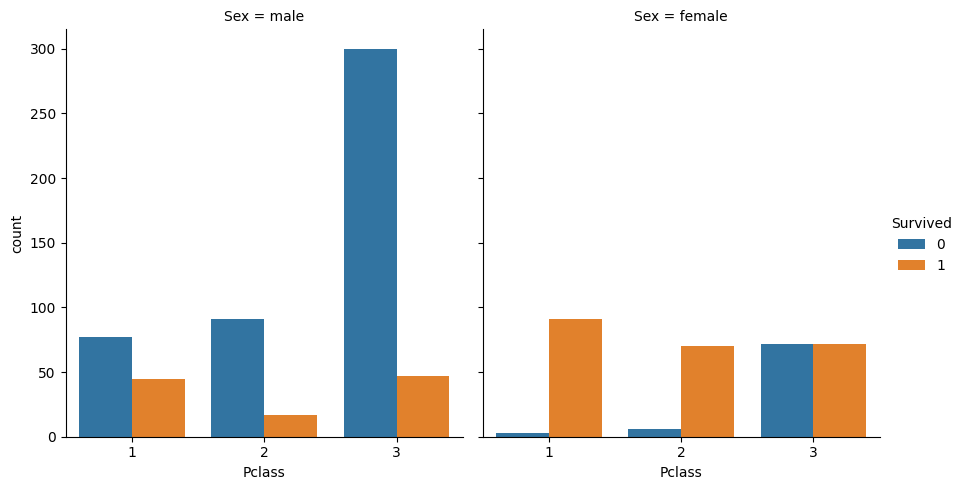

In [41]:
sns.catplot(
    data=df,
    x="Pclass",
    hue="Survived",
    col="Sex",
    kind="count",
    height=5,
    aspect=0.9
)

plt.show()

##### a. **Que représente ce graphique ?**

Le graphique est divisé en deux panneaux :
-   à gauche : les hommes ;
-   à droite : les femmes.

Dans chaque panneau, on compare les trois classes (Pclass) et le nombre de survivants/non-survivants.

##### b. **Ce que l'on observe:**

-   Les femmes présentent un taux de survie élevé dans les trois classes, particulièrement en première et deuxième classe.
-   Les hommes de troisième classe sont les plus nombreux parmi les non-survivants.
-   Les hommes de première classe semblent avoir davantage survécu que ceux des autres classes.

##### c. **Conclusion**

L'analyse conjointe du sexe et de la classe montre que ces deux variables influencent fortement la survie. Les femmes présentent des taux de survie élevés quelle que soit leur classe de voyage, tandis que les hommes de troisième classe apparaissent comme le groupe le plus vulnérable. Cette interaction suggère que le sexe et la classe combinés sont des variables particulièrement informatives pour prédire la survie.

##### 2. Age, Sex et Survived

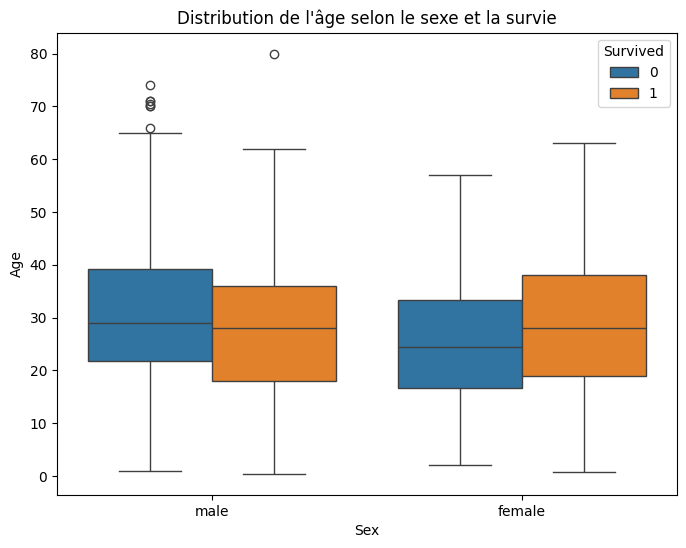

In [43]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Sex",
    y="Age",
    hue="Survived"
)

plt.title("Distribution de l'âge selon le sexe et la survie")

plt.show()

Conclusion de ce graphique : 

-   Les distributions d'âge des survivants et des non-survivants sont relativement proches chez les hommes comme chez les femmes. Les médianes ne présentent pas de différences très marquées.
-   La dispersion des âges est comparable entre les différents groupes. Des passagers de tous âges sont présents parmi les survivants comme parmi les non-survivants.
-   Quelques valeurs extrêmes sont observées dans chacun des groupes, notamment des passagers très jeunes et des personnes âgées. Ces observations restent cohérentes avec la composition de la population étudiée.

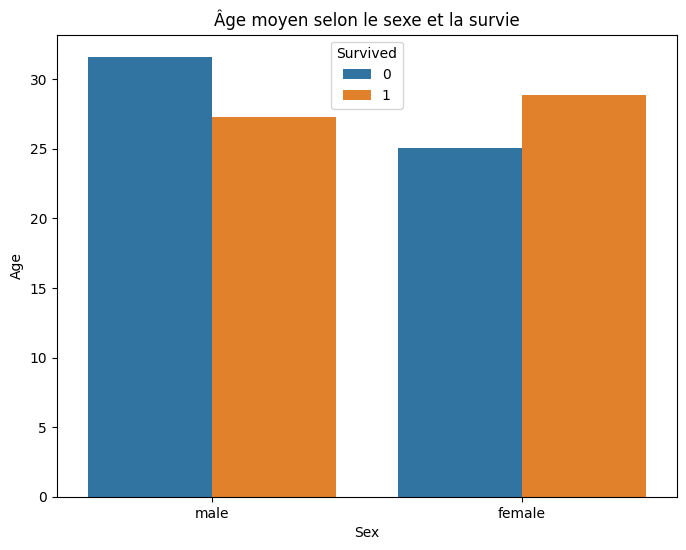

In [44]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x="Sex",
    y="Age",
    hue="Survived",
    errorbar=None
)

plt.title("Âge moyen selon le sexe et la survie")

plt.show()

**Conclusion** 

L'analyse conjointe de l'âge, du sexe et de la survie montre que les distributions d'âge sont relativement similaires entre les différents groupes de passagers. Le boxplot met en évidence des médianes et des dispersions proches, tandis que le barplot indique que les âges moyens des survivants et des non-survivants restent relativement comparables au sein de chaque sexe.

Ces résultats suggèrent que l'âge, considéré conjointement avec le sexe, ne permet pas de distinguer clairement les survivants des non-survivants. En revanche, le sexe apparaît comme un facteur plus discriminant, comme l'ont déjà montré les analyses bivariées. Ainsi, l'effet de l'âge semble plus limité lorsqu'il est étudié avec le sexe.

Cette analyse confirme que la survie des passagers est davantage influencée par le sexe que par l'âge, même si ce dernier peut apporter une information complémentaire dans le cadre de la modélisation.



##### 3. Embarked, Pclass et Survived

**Objectif**

Déterminer si l'influence du port d'embarquement sur la survie est la même selon la classe de voyage.


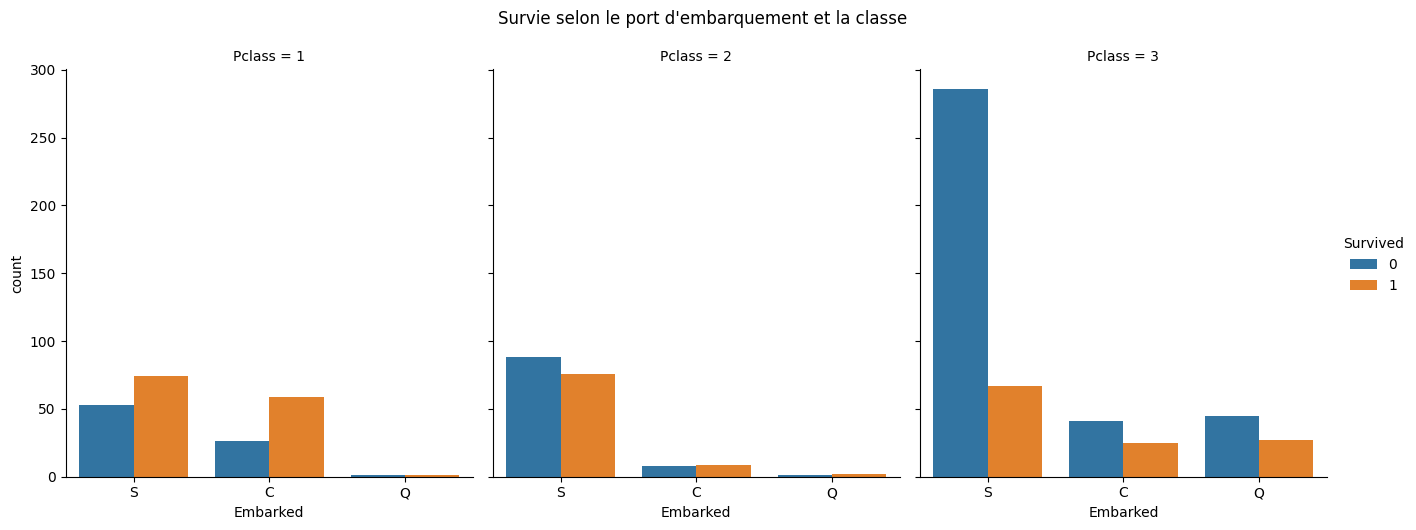

In [45]:
sns.catplot(
    data=df,
    x="Embarked",
    hue="Survived",
    col="Pclass",
    kind="count",
    height=5,
    aspect=0.9
)

plt.suptitle("Survie selon le port d'embarquement et la classe", y=1.05)

plt.show()

##### a. Que faut-il observer ?

Pour chaque classe (1, 2 et 3), compare :

-   les passagers embarqués à Southampton (S) ;
-   ceux embarqués à Cherbourg (C) ;
-   ceux embarqués à Queenstown (Q) ;

et observe la répartition entre survivants et non-survivants.

##### b. Pose-toi les questions suivantes :

-   Les proportions de survivants sont-elles identiques dans les trois ports ?
-   Une classe semble-t-elle plus favorisée selon le port d'embarquement ?

--> Réponses : 

-   L'analyse multivariée montre que la classe de voyage (Pclass) exerce une influence plus importante sur la survie que le port d'embarquement (Embarked). 

-   En effet, lorsque l'on compare les trois graphiques correspondant aux différentes classes, on observe des différences marquées des proportions de survivants et de non-survivants entre les classes. Les passagers de première classe présentent globalement de meilleures chances de survie, tandis que la troisième classe concentre la majorité des non-survivants.

-   En revanche, à l'intérieur d'une même classe, les différences entre les ports d'embarquement (S, C et Q) sont généralement moins prononcées. Bien que certaines variations puissent être observées, elles restent limitées par rapport aux écarts constatés entre les classes de voyage.

Ces résultats suggèrent que la classe de voyage est un facteur plus discriminant que le port d'embarquement pour expliquer la survie des passagers.

-   L'analyse multivariée montre que la classe de voyage (Pclass) exerce une influence plus importante sur la survie que le port d'embarquement (Embarked). 

-   En effet, lorsque l'on compare les trois graphiques correspondant aux différentes classes, on observe des différences marquées des proportions de survivants et de non-survivants entre les classes. Les passagers de première classe présentent globalement de meilleures chances de survie, tandis que la troisième classe concentre la majorité des non-survivants.

-   En revanche, à l'intérieur d'une même classe, les différences entre les ports d'embarquement (S, C et Q) sont généralement moins prononcées. Bien que certaines variations puissent être observées, elles restent limitées par rapport aux écarts constatés entre les classes de voyage.

Ces résultats suggèrent que la classe de voyage est un facteur plus discriminant que le port d'embarquement pour expliquer la survie des passagers.

##### c. Explication : 

Il faut comprendre ce que fait l'analyse multivariée.
En analyse bivariée, tu avais observé que : Embarked --> Survived

Il semblait exister une différence de survie selon le port.

Mais avec l'analyse multivariée, tu ajoutes la variable Pclass.
Tu observes alors que les différences de survie sont principalement liées au changement de classe, et beaucoup moins au changement de port.
Autrement dit :

-   lorsque tu passes de la 1ʳᵉ à la 3ᵉ classe, la répartition entre survivants et non-survivants change fortement ;
-   lorsque tu restes dans une même classe et que tu compares les ports (S, C, Q), les différences sont souvent plus modestes.

Cela indique que la classe explique une plus grande part des variations de survie que la variable embarked.


##### d. Une interprétation "métier"? 

-   Cette conclusion est également cohérente avec le contexte historique du Titanic.

-   La classe de voyage reflétait les conditions d'accès aux ponts, la localisation des cabines et, plus généralement, la position sociale des passagers. Ces éléments ont probablement influencé les possibilités d'évacuation.

-   À l'inverse, le port d'embarquement (Southampton, Cherbourg ou Queenstown) n'a pas, en lui-même, de raison directe d'influencer les chances de survie. Son effet est davantage indirect, car les passagers embarquant dans un même port n'appartenaient pas tous aux mêmes classes de voyage.

##### 4. Fare, Pclass et Survived

**Objectif**

Étudier conjointement l'influence du prix du billet (Fare) et de la classe de voyage (Pclass) sur la survie des passagers (Survived), afin de déterminer si le tarif apporte une information supplémentaire au-delà de la classe.

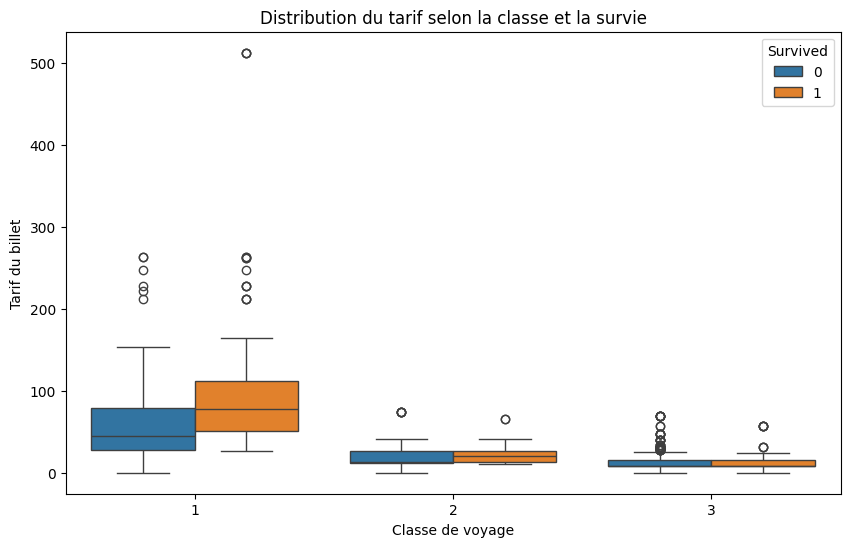

In [48]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Fare",
    hue="Survived"
)

plt.title("Distribution du tarif selon la classe et la survie")
plt.xlabel("Classe de voyage")
plt.ylabel("Tarif du billet")

plt.show()

##### a. Comment analyser ce graphique ?

Pour chaque classe (1, 2 et 3), observe :
-   la médiane (trait au centre de la boîte) ;
-   la dispersion des tarifs (taille de la boîte) ;
-   les valeurs extrêmes (points isolés) ;
-   les différences entre survivants et non-survivants.






#####  b. Analyse
-   Première classe
    -   Les passagers de première classe ont payé les tarifs les plus élevés.
    -   La dispersion des tarifs est importante : certains billets sont très coûteux tandis que d'autres sont nettement moins chers.
    -   Les survivants présentent généralement des tarifs légèrement plus élevés que les non-survivants, mais les distributions se chevauchent largement.

-   Deuxième classe
    -   Les tarifs sont plus faibles que ceux de la première classe.
    -   La dispersion est moins importante.
    -   Les distributions des survivants et des non-survivants sont relativement proches.

-   Troisième classe
    -   Les billets sont les moins chers.
    -   La dispersion est faible, avec quelques valeurs atypiques.
    -   Les différences de tarif entre survivants et non-survivants sont peu marquées.

##### c. Interprétation - cette analyse met en évidence que :

-   le tarif est fortement lié à la classe de voyage ;
-   les passagers de première classe ont payé des billets nettement plus chers ;
-   la survie est globalement meilleure en première classe.
-   Le prix du billet apporte donc une information sur la position sociale du passager, mais cette information est en grande partie déjà portée par la variable Pclass.


##### d. Conclusion

L'analyse multivariée montre que le tarif du billet varie fortement selon la classe de voyage. 
Les passagers de première classe ont payé les montants les plus élevés, tandis que ceux de troisième classe ont payé les tarifs les plus faibles. 
Les survivants présentent généralement des tarifs légèrement supérieurs à ceux des non-survivants au sein d'une même classe, bien que les distributions restent largement superposées. 
Ces résultats suggèrent que le tarif constitue une variable informative pour expliquer la survie, mais son influence est fortement liée à celle de la classe de voyage. 
Ainsi, Fare et Pclass apportent des informations complémentaires, tout en étant étroitement associées.

##### 5. Age, Pclass et Survived

**Objectif**

Étudier conjointement l'âge (Age), la classe de voyage (Pclass) et la survie (Survived) afin d'identifier d'éventuelles différences dans la distribution des âges des survivants et des non-survivants selon la classe de voyage.


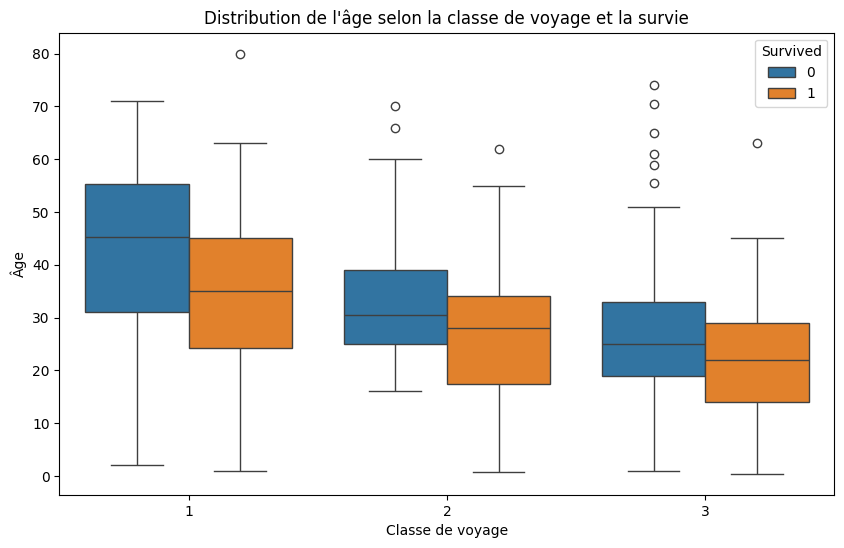

In [49]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Survived"
)

plt.title("Distribution de l'âge selon la classe de voyage et la survie")
plt.xlabel("Classe de voyage")
plt.ylabel("Âge")

plt.show()

##### a. Analyse

-   Première classe
    -   Les survivants et les non-survivants présentent des distributions d'âge relativement proches.
    -   Les médianes sont similaires.
    -   On observe une large dispersion des âges.
👉 L'âge ne semble pas distinguer fortement les survivants des non-survivants dans cette classe.

-   Deuxième classe
    -   Les distributions sont également assez proches.
    -   Quelques différences peuvent apparaître, mais elles restent limitées.
👉 L'effet de l'âge demeure modéré.

-   Troisième classe
    -   La population est globalement plus jeune.
    -   Les distributions montrent parfois une proportion plus importante de jeunes survivants.
    -   On observe également davantage de très jeunes passagers.
👉 L'âge semble jouer un rôle un peu plus marqué dans cette classe, sans toutefois créer une séparation nette entre survivants et non-survivants.

##### b. Interprétation

Cette analyse met en évidence que :
-   la classe de voyage reste le facteur le plus discriminant ;
-   l'âge apporte une information complémentaire, mais son influence varie peu d'une classe à l'autre ;
-   les distributions des survivants et des non-survivants restent largement superposées.

**Autrement dit, il est difficile de prédire la survie uniquement à partir de l'âge, même lorsque l'on tient compte de la classe.**

##### c. Conclusion

-   L'analyse multivariée montre que les distributions d'âge des survivants et des non-survivants restent relativement proches au sein de chaque classe de voyage. 
-   Bien que certaines différences soient observées, notamment en troisième classe où les jeunes passagers semblent légèrement mieux représentés parmi les survivants, les distributions se chevauchent largement. 
-   La classe de voyage apparaît donc comme un facteur plus discriminant que l'âge pour expliquer la survie. 
-   L'âge constitue néanmoins une variable complémentaire qui pourra contribuer à améliorer les performances du modèle lorsqu'il sera combiné à d'autres variables explicatives.



##### 6. **Conclusion – Analyse multivariée**

-   L'analyse multivariée a permis d'étudier simultanément plusieurs variables afin de mieux comprendre les facteurs influençant la survie des passagers du Titanic. Contrairement aux analyses univariées et bivariées, elle met en évidence les interactions entre les variables explicatives et montre que la survie ne dépend pas d'un seul facteur.

-   Les résultats confirment que le sexe et la classe de voyage (Pclass) sont les variables les plus discriminantes. Les femmes et les passagers de première classe présentent globalement des probabilités de survie plus élevées que les hommes et les passagers de troisième classe.

-   L'âge apporte une information complémentaire, mais son influence apparaît moins marquée. Les distributions d'âge des survivants et des non-survivants restent relativement proches, même si certaines différences peuvent être observées selon le sexe ou la classe.

-   Le prix du billet (Fare) est fortement associé à la classe de voyage. Les passagers ayant payé les tarifs les plus élevés appartiennent majoritairement aux classes supérieures, qui présentent également de meilleurs taux de survie. Le tarif constitue donc une variable informative, mais son effet est en partie lié à celui de la classe.

-   Enfin, le port d'embarquement (Embarked) apporte une information complémentaire, mais son influence semble moins importante que celle de la classe de voyage. Les différences observées entre les ports s'expliquent en grande partie par la répartition des passagers dans les différentes classes.

Dans l'ensemble, ces analyses montrent que la survie résulte de la combinaison de plusieurs caractéristiques des passagers. Elles confirment que certaines variables sont plus influentes que d'autres et mettent en évidence des relations entre variables explicatives, notamment entre le tarif et la classe de voyage. Ces observations serviront de base à la phase de prétraitement, de sélection des variables et de construction des modèles de Machine Learning.







### 5.4 - Corrélations 

**Objectif**

L'objectif de cette analyse est d'étudier les relations linéaires entre les variables numériques du jeu de données. La matrice de corrélation permet d'identifier les variables les plus liées à la survie ainsi que les éventuelles corrélations entre variables explicatives, ce qui peut être utile pour la phase de modélisation.

#### 1. Préparation des données


La corrélation ne peut être calculée que sur des variables numériques. Il faut donc encoder la variable Sex pour pouvoir l'inclure.

In [50]:
df_corr = df.copy()

df_corr["Sex"] = df_corr["Sex"].map({"male": 0, "female": 1})

df_corr["Embarked"] = df_corr["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

#### 2. Calcul de la matrice de corrélation




In [51]:
corr = df_corr.corr(numeric_only=True)

corr

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,0.036847,-0.057527,-0.001652,0.012658,-0.030555
Survived,-0.005007,1.000000,-0.338481,0.543351,-0.077221,-0.035322,0.081629,0.257307,0.108669
Pclass,-0.035144,-0.338481,1.000000,-0.131900,-0.369226,0.083081,0.018443,-0.549500,0.043835
Sex,-0.042939,0.543351,-0.131900,1.000000,-0.093254,0.114631,0.245489,0.182333,0.118593
Age,0.036847,-0.077221,-0.369226,-0.093254,1.000000,-0.308247,-0.189119,0.096067,0.012186
SibSp,-0.057527,-0.035322,0.083081,0.114631,-0.308247,1.000000,0.414838,0.159651,-0.060606
Parch,-0.001652,0.081629,0.018443,0.245489,-0.189119,0.414838,1.000000,0.216225,-0.079320
Fare,0.012658,0.257307,-0.549500,0.182333,0.096067,0.159651,0.216225,1.000000,0.063462
Embarked,-0.030555,0.108669,0.043835,0.118593,0.012186,-0.060606,-0.079320,0.063462,1.000000


#### 3. Visualisation






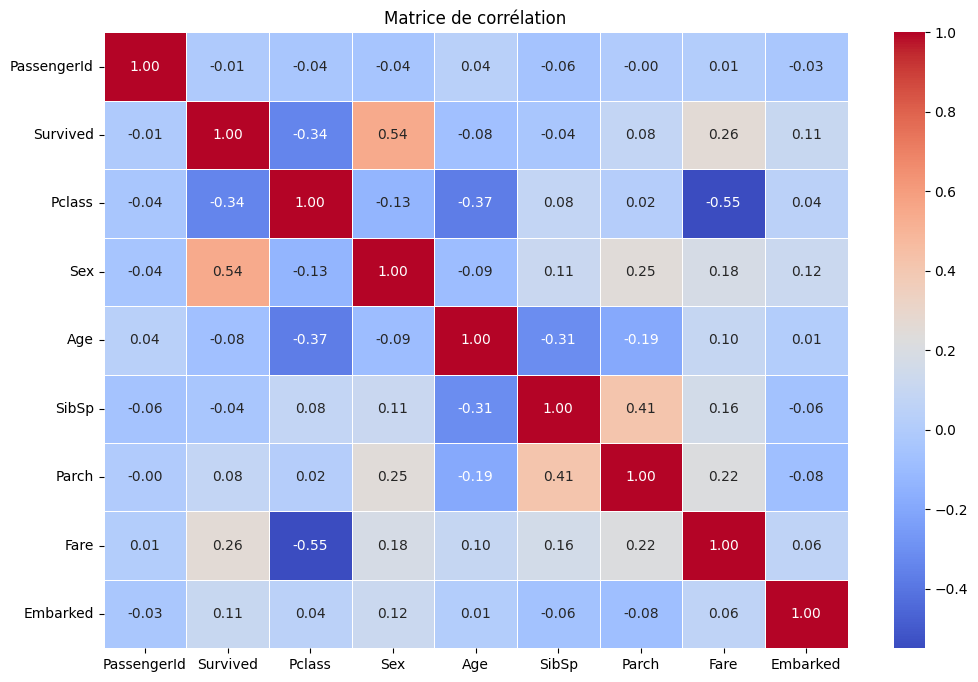

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matrice de corrélation")

plt.show()

#### 4. Analyse des corrélations - Conclusion

Tu peux observer notamment les corrélations entre Survived et les autres variables.

Sur le dataset Titanic classique, on obtient généralement :

-   Sex présente la corrélation la plus forte avec Survived.
-   Pclass est négativement corrélée avec Survived (plus le numéro de classe est élevé, moins la probabilité de survie est importante).
-   Fare est positivement corrélée avec Survived.
-   Age présente une corrélation faible.
-   SibSp et Parch présentent également des corrélations faibles.
-   Il est également fréquent d'observer une corrélation notable entre Pclass et Fare, car les passagers de première classe payaient généralement des billets plus chers.

**Conclusion**

-   L'analyse de la matrice de corrélation confirme les observations réalisées au cours des analyses exploratoires. 
-   Les variables Sex, Pclass et Fare apparaissent comme les plus liées à la variable cible Survived, tandis que Age, SibSp et Parch présentent des corrélations plus faibles. 
-   Une corrélation est également observée entre Fare et Pclass, ce qui est cohérent avec le fait que les passagers de première classe payaient généralement des billets plus élevés. 
-   Dans l'ensemble, aucune corrélation extrêmement forte entre les variables explicatives n'est observée, ce qui laisse penser qu'elles apportent des informations complémentaires pour la modélisation.




#### 5. Tests statistiques si nécessaires

**Objectif**

Les analyses graphiques permettent d'observer des tendances, mais elles ne permettent pas de conclure si les différences observées sont statistiquement significatives. Les tests statistiques permettent de valider ces observations en évaluant si les relations entre les variables sont susceptibles d'être dues au hasard.

##### **1. Rappel des choses à savoir sur les tests** 

##### Cas 1 - Si on compare deux variables catégorielles : Test du Chi2 

Question que l'on se pose : Existe-t-il une relation entre ces deux variables ?

Hypothèses

-   H₀ : les variables sont indépendantes.
-   H₁ : elles sont liées.

##### Cas 2 - Comparer une variable numérique entre deux groupes

-   Ex : 
    -   Âge des survivants vs âge des non-survivants.
    -   Tarif des survivants vs tarif des non-survivants.

-   Cas A : les données suivent une loi normale → Test t de Student

    -   Question : Les moyennes sont-elles différentes ?


-   Cas B : les données ne sont pas normales → Test de Mann-Whitney
    
    -   Question : Les distributions sont-elles différentes ?

##### Cas 3 - Comparer une variable numérique entre plus de deux groupes

-   Exemple : Âge selon les trois classes (Pclass).

    -   Cas A : normalité → ANOVA

        -   Question : Les moyennes des différents groupes sont-elles identiques ?
   
    -   Cas B : pas de normalité → Kruskal-Wallis
        
        -   Question : Les distributions des groupes sont-elles différentes ?


##### Cas 4 -  Mesurer une relation entre deux variables numériques

-   Exemples :
    -   Age ↔ Fare
    -   Fare ↔ SibSp

-   Cas A : relation linéaire → Corrélation de Pearson

    -   Question : Existe-t-il une relation linéaire ?     

-   Cas B : relation monotone ou données non normales → Corrélation de Spearman

    -   Question : Existe-t-il une relation monotone ?  

##### Cas 5 -  Vérifier la normalité d'une variable

-   Exemple : L'âge suit-il une loi normale ?
-   Test : Shapiro-Wilk

Pourquoi ?
Avant de choisir entre un test paramétrique (Student, ANOVA) et un test non paramétrique (Mann-Whitney, Kruskal-Wallis).

##### Cas 6 - Vérifier l'égalité des variances

-   Exemple : Comparer les âges de deux groupes.
-   Test : Levene

Pourquoi ?
Le test t de Student suppose que les variances sont comparables.


##### Remarque : Quel est le but de ces tests ? 

-   Valider les observations de l'EDA
-   Éviter des conclusions trompeuses
-   Hiérarchiser les variables 
    -   par exemple si on a p-value(Sex) < 0.001 ; p-value(Pclass) < 0.001 ; p-value(Embarked) = 0.18
    -   On en conclue que Sex et Pclass sont fortement associé à Survived, Embarked ne montre pas de relation statistiquement significative dans cet exemple.
-   Renforcer la crédibilité de ton étude


#### 2. - Tests du Chi2 - Sex et Survived 

**Pourquoi ce test ?**

Les deux variables sont catégorielles :

-   Sex
-   Survived

Le test du Chi² permet de vérifier si elles sont indépendantes ou non.

**Hypothèses**
H₀ : le sexe et la survie sont indépendants.
H₁ : le sexe et la survie sont liés.

In [53]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["Sex"], df["Survived"])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Statistique du Chi² :", chi2)
print("p-value :", p)

Statistique du Chi² : 260.71702016732104
p-value : 1.197357062775565e-58


**Interprétation**



In [54]:
alpha = 0.05

if p < alpha:
    print("On rejette H0 : il existe une relation entre le sexe et la survie.")
else:
    print("On ne rejette pas H0.")

    

On rejette H0 : il existe une relation entre le sexe et la survie.


**Conclusion**

Le test du Chi² met en évidence une relation statistiquement significative entre le sexe et la survie (p < 0,05). Le sexe constitue donc un facteur explicatif important de la survie des passagers, ce qui confirme les observations réalisées lors des analyses bivariées et multivariées.

#### 3. Tests du Chi2 - Pclass et Survived 

**Pourquoi ce test ?**

Les deux variables sont catégorielles :

-   Pclass
-   Survived

Le test du Chi² permet de vérifier si elles sont indépendantes ou non.

**Hypothèses**
H₀ : la classe et la survie sont indépendants.
H₁ : la classe et la survie sont liés.

In [55]:
contingency = pd.crosstab(df["Pclass"], df["Survived"])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Statistique du Chi² :", chi2)
print("p-value :", p)

Statistique du Chi² : 102.88898875696056
p-value : 4.549251711298793e-23


**Interprétation**

In [56]:
alpha = 0.05

if p < alpha:
    print("On rejette H0 : la classe influence la survie.")
else:
    print("On ne rejette pas H0.")

On rejette H0 : la classe influence la survie.


**Conclusion**

Les résultats montrent que la classe de voyage est significativement liée à la survie des passagers. Cette conclusion confirme les analyses exploratoires, qui avaient déjà mis en évidence une probabilité de survie plus élevée chez les passagers des classes supérieures.

#### 4. Test de Mann-Whitney : Âge et Survie

**Objectif**

Comparer la distribution des âges entre :

-   les survivants ;
-   les non-survivants.

**Hypothèses**

H₀ : les distributions d'âge sont identiques.
H₁ : elles sont différentes.




In [58]:
from scipy.stats import mannwhitneyu

survivants = df[df["Survived"] == 1]["Age"].dropna()
non_survivants = df[df["Survived"] == 0]["Age"].dropna()

stat, p = mannwhitneyu(survivants, non_survivants)

print("Statistique :", stat)
print("p-value :", p)

Statistique : 57682.0
p-value : 0.1604925247773774


**Interprétation**

In [59]:
alpha = 0.05

if p < alpha:
    print("Les distributions d'âge sont significativement différentes.")
else:
    print("Aucune différence significative n'est observée.")

Aucune différence significative n'est observée.


**Conclusion**

Le test de Mann-Whitney permet de déterminer si les différences d'âge observées entre survivants et non-survivants sont statistiquement significatives. Selon la valeur de la p-value, on pourra conclure que l'âge est, ou non, un facteur associé à la survie.

#### 5. Conclusion de la partie 5.5 - Tests statistiques si nécéssaires

Les tests statistiques confirment les principales observations réalisées au cours de l'analyse exploratoire. Les variables Sex et Pclass présentent une relation statistiquement significative avec la variable cible Survived, ce qui renforce leur intérêt pour la modélisation. Le test appliqué à l'âge permet d'évaluer si les différences observées entre survivants et non-survivants sont significatives. Ces résultats confirment que les tendances mises en évidence par les visualisations reposent sur des relations statistiquement fondées et non sur de simples fluctuations aléatoires.

#### 5.6 - Conclusions 

L'analyse exploratoire des données a permis de mieux comprendre la structure du jeu de données Titanic, d'évaluer sa qualité et d'identifier les principaux facteurs susceptibles d'influencer la survie des passagers.

-   **Les analyses univariées ont mis en évidence les caractéristiques générales des différentes variables. Elles ont notamment montré une répartition déséquilibrée de la variable cible Survived, une prédominance des passagers de troisième classe, une majorité d'hommes à bord ainsi qu'une forte concentration des âges entre 20 et 40 ans. L'étude des variables numériques a également révélé la présence de valeurs extrêmes, en particulier pour le tarif des billets (Fare), sans pour autant remettre en cause la cohérence globale des données.**

-   **Les analyses bivariées ont permis d'identifier plusieurs relations importantes avec la variable cible. Le sexe et la classe de voyage apparaissent comme les variables les plus fortement associées à la survie. Les femmes présentent un taux de survie nettement supérieur à celui des hommes, tandis que les passagers de première classe survivent davantage que ceux des classes inférieures. L'âge et le tarif du billet apportent également des informations pertinentes, bien que leur influence soit moins marquée.**

-   **Les analyses multivariées ont confirmé que la survie résulte de l'interaction de plusieurs variables plutôt que de l'effet d'un facteur unique. Elles montrent notamment que le sexe et la classe de voyage demeurent les variables les plus discriminantes, tandis que le tarif du billet est fortement lié à la classe de voyage. Le port d'embarquement et l'âge apportent une information complémentaire, mais leur influence apparaît plus limitée lorsqu'ils sont étudiés conjointement avec les autres variables.**

-   **L'étude de la matrice de corrélation confirme ces observations en mettant en évidence une corrélation notable entre la survie et certaines variables telles que Sex, Pclass et Fare. Les corrélations entre les variables explicatives restent toutefois modérées, ce qui suggère qu'elles apportent des informations complémentaires pour la modélisation.**

-   **Enfin, les tests statistiques réalisés permettent de valider les principales observations issues des analyses graphiques. Ils confirment que les relations observées entre certaines variables explicatives et la variable cible sont statistiquement significatives et ne sont pas uniquement dues au hasard.**

Dans l'ensemble, cette analyse exploratoire met en évidence que les variables Sex, Pclass, Fare et, dans une moindre mesure, Age constituent les variables les plus prometteuses pour la prédiction de la survie. Elle a également permis d'identifier plusieurs points qui devront être pris en compte lors de la phase de prétraitement, notamment le traitement des valeurs manquantes, l'encodage des variables catégorielles, la gestion des valeurs extrêmes ainsi que la sélection des variables les plus pertinentes.

Cette étude constitue ainsi une base solide pour la prochaine étape du projet, qui consistera à préparer les données en vue de l'entraînement et de l'évaluation des modèles de Machine Learning.


### **Etape 6 - Synthèse des variables pour la modélisation**

#### Les étapes de la synthèse

1. Variables les plus pertinentes
2. Variables peu pertinentes
3. Variables nécessitant un prétraitement
4. Synthèse des décisions de prétraitement
5. Conclusion

#### 6.1 - Variables les plus pertinentes 

Les analyses exploratoires ont permis d'identifier les variables présentant la plus forte relation avec la variable cible Survived.

Les variables Sex et Pclass apparaissent comme les plus discriminantes. Les analyses bivariées, multivariées, les corrélations ainsi que les tests statistiques confirment leur influence significative sur la probabilité de survie.

La variable Fare apporte également une information pertinente, bien que son effet soit partiellement lié à la classe de voyage. L'âge (Age) contribue également à l'explication de la survie, mais son influence reste plus modérée. 

Enfin, la variable Embarked apporte une information complémentaire, dont l'effet semble moins marqué que celui des variables précédentes.

#### 6.2 - Variables peu pertinentes

Certaines variables semblent présenter un intérêt limité dans leur forme actuelle:

-   **PassengerId** est un identifiant technique qui n'apporte aucune information explicative sur la survie.

-   **Ticket** possède un grand nombre de modalités et ne montre pas de relation directe avec la variable cible. Une éventuelle exploitation nécessiterait un travail de **Feature Engineering**.

-   **Name** est une variable descriptive qui n'est pas directement exploitable. Toutefois, l'extraction du titre de civilité (Mr, Mrs, Miss, etc.) pourrait constituer une piste d'amélioration.

-   **Cabin** pourra être supprimée ou transformée en fonction de la stratégie retenue pour gérer les valeurs manquantes.

#### 6.3 - Variables nécessitant un prétraitement

L'analyse exploratoire a mis en évidence plusieurs traitements à effectuer avant la phase de modélisation.

-   La variable **Age** contient des valeurs manquantes qui devront être imputées.
-   La variable **Embarked** présente également quelques valeurs manquantes qui devront être complétées.
-   La variable **Cabin** comporte une proportion importante de valeurs manquantes. Son maintien ou sa suppression devra être étudié lors du prétraitement.
-   Les variables **catégorielles** **Sex** et **Embarked** devront être encodées afin d'être exploitables par les algorithmes de Machine Learning.
-   Les variables **numériques** pourront être **normalisées ou standardisées** selon les exigences des modèles utilisés.

#### 6.4 - Synthèse des décisions de prétraitement

| Variable    | Décision envisagée             | Justification                                        |
| ----------- | ------------------------------ | -----------------------------------------------------|
| PassengerId | Supprimer                      | Identifiant sans pouvoir prédictif                   |
| Survived    | Conserver                      | Variable cible                                       |
| Pclass      | Conserver                      | Variable fortement liée à la survie                  |
| Name        | À transformer ou supprimer     | Possibilité d'extraire le titre de civilité          |
| Sex         | Conserver et encoder           | Variable fortement discriminante                     |
| Age         | Conserver et imputer           | Valeurs manquantes et information pertinente         |
| SibSp       | Conserver                      | Variable potentiellement informative                 |
| Parch       | Conserver                      | Variable potentiellement informative                 |
| Ticket      | À supprimer ou transformer.    | Faible intérêt dans sa forme actuelle                |
| Fare        | Conserver                      | Variable informative                                 |
| Cabin       | À supprimer ou transformer     | Trop nombreuses valeurs manquantes                   |
| Embarked    | Conserver, imputer et encoder  | Variable catégorielle avec peu de valeurs manquantes |






#### 6.5 - Conclusion

L'analyse exploratoire a permis d'identifier les variables les plus prometteuses pour la prédiction de la survie des passagers. 

Les variables **Sex, Pclass, Fare, Age et Embarked** seront conservées pour la modélisation, après les opérations de prétraitement nécessaires. 

Les variables **PassengerId, Ticket, Name et Cabin** feront l'objet d'une réflexion spécifique, pouvant conduire à leur suppression ou à la création de nouvelles variables par Feature Engineering. 

Cette synthèse constitue le point de départ de la prochaine étape du projet, consacrée au prétraitement et à la préparation des données pour l'entraînement des modèles de Machine Learning.

### **Etape 7 : Conclusion générale de l'EDA**

L'analyse exploratoire des données (EDA) a permis d'acquérir une compréhension approfondie du jeu de données Titanic et d'identifier les principales caractéristiques des passagers susceptibles d'influencer leur survie.

Dans un premier temps, l'étude de la structure du dataset a permis de comprendre la nature des différentes variables, de distinguer les variables numériques et catégorielles, ainsi que d'identifier la variable cible Survived. L'analyse de la qualité des données a ensuite mis en évidence la présence de valeurs manquantes, notamment dans les variables Age, Cabin et Embarked, ainsi que quelques valeurs extrêmes pour la variable Fare. En revanche, aucun doublon n'a été détecté et les types de données se sont révélés cohérents avec leur signification.

Les analyses statistiques ont permis de mieux comprendre la distribution des variables ainsi que leurs relations avec la variable cible. Les analyses univariées ont décrit les caractéristiques propres à chaque variable, tandis que les analyses bivariées et multivariées ont montré que la survie dépendait de plusieurs facteurs combinés. Les variables Sex et Pclass apparaissent comme les facteurs les plus discriminants, tandis que Fare, Age et Embarked apportent des informations complémentaires. Les corrélations et les tests statistiques ont permis de confirmer ces observations et de renforcer la validité des conclusions tirées des visualisations.

L'EDA a également permis d'identifier les principales opérations de préparation des données qui devront être réalisées avant la modélisation. Celles-ci incluent le traitement des valeurs manquantes, l'encodage des variables catégorielles, la gestion des valeurs extrêmes lorsque cela sera nécessaire, ainsi que la sélection ou la transformation de certaines variables telles que Cabin, Ticket et Name.

Cette étape exploratoire constitue un élément essentiel du projet, car elle permet de construire une stratégie de prétraitement fondée sur une compréhension approfondie des données plutôt que sur des choix arbitraires. Les connaissances acquises au cours de cette analyse serviront directement à préparer un jeu de données propre, cohérent et exploitable par les algorithmes de Machine Learning.

La prochaine étape du projet consistera donc à mettre en œuvre ces opérations de prétraitement afin de produire un jeu de données prêt pour l'entraînement, la comparaison et l'évaluation des différents modèles de classification.